# Baseline 6 Leaderboard

모델 버전과 피처 버전 조합별 3그룹 평균 성능을 비교합니다.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path("D:/workspaces/WINDFORCE")
results = pd.read_csv(ROOT / "BASELINE/baseline_6_results.csv")
summary = (results.groupby(["model_version", "feature_version"], as_index=False).agg(mean_nmae=("nmae", "mean"), mean_ficr=("ficr", "mean"), mean_score=("score", "mean"), groups=("group", "nunique"), mean_features=("n_features", "mean")).sort_values("mean_score", ascending=False))
display(summary)

,model_version,feature_version,mean_nmae,mean_ficr,mean_score,groups,mean_features
5,v2,corr_filtered,0.193969,0.172851,0.489441,3,104.0
1,v1,corr_filtered,0.190235,0.162044,0.485904,3,104.0
8,v3,all,0.197439,0.146128,0.474344,3,111.0
10,v3,pca,0.197689,0.144080,0.473195,3,6.0
6,v2,pca,0.199484,0.136273,0.468394,3,6.0
11,v3,tree_importance,0.201711,0.137143,0.467716,3,39.0
2,v1,pca,0.200712,0.127672,0.463480,3,6.0
9,v3,corr_filtered,0.198579,0.119606,0.460513,3,104.0
7,v2,tree_importance,0.206367,0.110943,0.452288,3,39.0
0,v1,all,0.201370,0.105387,0.452009,3,111.0


In [4]:
display(summary.groupby("model_version", as_index=False)[["mean_nmae", "mean_ficr", "mean_score"]].mean().sort_values("mean_score", ascending=False))
display(summary.groupby("feature_version", as_index=False)[["mean_nmae", "mean_ficr", "mean_score", "mean_features"]].mean().sort_values("mean_score", ascending=False))

,model_version,mean_nmae,mean_ficr,mean_score
2,v3,0.198855,0.136739,0.468942
1,v2,0.200789,0.128900,0.464055
0,v1,0.197439,0.123739,0.463150


,feature_version,mean_nmae,mean_ficr,mean_score,mean_features
1,corr_filtered,0.194261,0.151500,0.478620,104.0
2,pca,0.199295,0.136008,0.468357,6.0
0,all,0.200716,0.115682,0.457483,111.0
3,tree_importance,0.201838,0.115980,0.457071,39.0


feature_version,all,corr_filtered,pca,tree_importance
model_version,,,,
v1,0.4520,0.4859,0.4635,0.4512
v2,0.4461,0.4894,0.4684,0.4523
v3,0.4743,0.4605,0.4732,0.4677


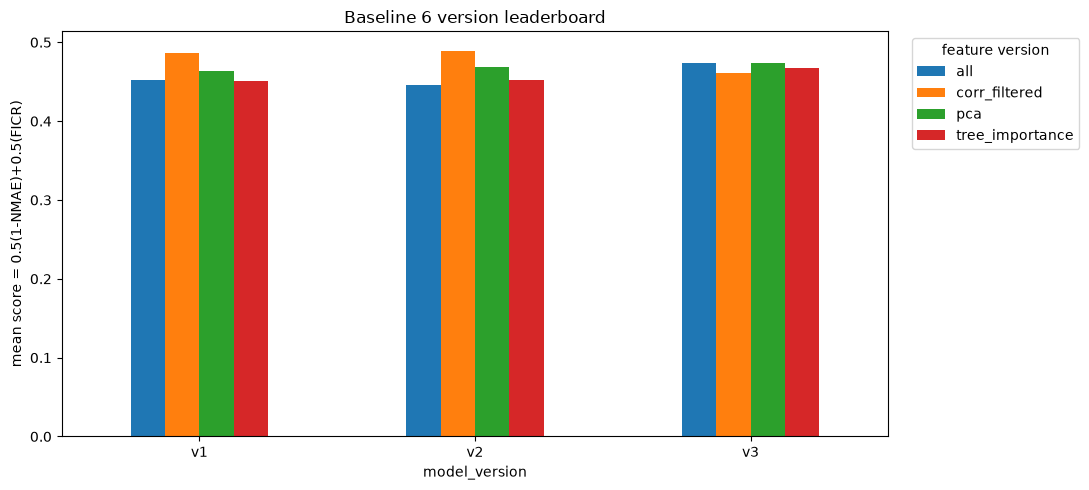

In [5]:
pivot = summary.pivot(index="model_version", columns="feature_version", values="mean_score")
display(pivot.style.format("{:.4f}").background_gradient(cmap="Blues"))
ax = pivot.plot(kind="bar", figsize=(11, 5), rot=0)
ax.set_ylabel("mean score = 0.5(1-NMAE)+0.5(FICR)")
ax.set_title("Baseline 6 version leaderboard")
ax.legend(title="feature version", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()